# Regressão Logística — Baseline
Validação temporal por expanding window (sempre testando em 2024).
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [17]:
import json
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

BASE_DIR     = '../../data/features/baseline'
OUTPUT_MOD   = '../../output/modelos'
OUTPUT_MET   = '../../output/metricas'
ALGO         = 'logistic_regression'
DATASET      = 'baseline'
RANDOM_STATE = 42

## 1. Carregamento dos dados

In [18]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

with open(os.path.join(BASE_DIR, 'config.json')) as f:
    config = json.load(f)

TRAIN_YEARS = config['train_years']
YEAR_COL    = config['split_col']

print(f'X_train: {X_train.shape} | y_train óbitos: {int(y_train.sum()):,} ({y_train.mean()*100:.2f}%)')
print(f'X_test:  {X_test.shape}  | y_test  óbitos: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')

X_train: (149544, 52) | y_train óbitos: 2,625 (1.76%)
X_test:  (160534, 52)  | y_test  óbitos: 5,295 (3.30%)


## 2. Preprocessamento

In [19]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]
SYMP_COLS = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','AUTO_IMUNE',
]
SYMP_COLS = [c for c in SYMP_COLS if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        # Sinais de alarme/gravidade: NaN informativo → 0
        ('alrm_grav',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS + GRAV_COLS),

        # Sintomas binários: NaN residual → moda
        ('sintomas',
         SimpleImputer(strategy='most_frequent'),
         SYMP_COLS),

        # Idade: outlier > 120 → NaN → mediana → escala
        ('age',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['age_years']),

        # epi_week: mediana → escala
        ('epi',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['epi_week']),

        # CS_SEXO: encode F→0/M→1 → moda
        ('sexo',
         Pipeline([
             ('enc', OrdinalEncoder(categories=[['F','M']],
                                    handle_unknown='use_encoded_value',
                                    unknown_value=np.nan)),
             ('imp', SimpleImputer(strategy='most_frequent')),
         ]),
         ['CS_SEXO']),

        # CS_ESCOL_N: ordinal com ordem natural (0=sem escolaridade … 7=superior completo)
        ('escol',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['CS_ESCOL_N']),

        # CS_RACA: categórica nominal — one-hot (sem ordem entre raças)
        ('raca',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_RACA']),

        # CS_GESTANT: categórica com categorias especiais — one-hot
        ('gestant',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_GESTANT']),

        # SG_UF: encode ordinal (sem ordem semântica, mas baixo impacto em LR)
        ('uf',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['SG_UF']),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print('Preprocessador definido.')

Preprocessador definido.


## 3. Funções auxiliares

In [20]:
def calcular_metricas(y_true, y_pred_proba, threshold=0.5, label=''):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'label':          label,
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
        'n_train':        None,
        'n_obito_train':  None,
    }

def build_pipeline():
    return Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
            solver='lbfgs',
        )),
    ])

def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

print('Funções definidas.')

Funções definidas.


## 4. Expanding window — validação temporal
Treino acumulado sobre anos anteriores, teste sempre em 2024.

In [21]:
X_test_prep = prep_X(X_test)
resultados  = []

for i in range(1, len(TRAIN_YEARS) + 1):
    anos_treino = TRAIN_YEARS[:i]
    label = '+'.join(str(a) for a in anos_treino)

    mask = X_train[YEAR_COL].isin(anos_treino)
    X_w  = prep_X(X_train[mask])
    y_w  = y_train[mask].dropna()
    X_w  = X_w.loc[y_w.index]

    pipe = build_pipeline()
    pipe.fit(X_w, y_w)

    proba = pipe.predict_proba(X_test_prep)[:, 1]
    y_te  = y_test.dropna()
    proba = proba[y_test.notna().values]

    metricas = calcular_metricas(y_te, proba, label=label)
    metricas['n_train']       = len(X_w)
    metricas['n_obito_train'] = int(y_w.sum())
    resultados.append(metricas)

    print(f'[{label}] Sensibilidade={metricas["sensibilidade"]:.4f} | '
          f'AUPRC={metricas["auprc"]:.4f} | ROC-AUC={metricas["roc_auc"]:.4f}')

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

[2020] Sensibilidade=0.7877 | AUPRC=0.6059 | ROC-AUC=0.9162
[2020+2021] Sensibilidade=0.7968 | AUPRC=0.6076 | ROC-AUC=0.9169
[2020+2021+2022] Sensibilidade=0.7964 | AUPRC=0.6206 | ROC-AUC=0.9208
[2020+2021+2022+2023] Sensibilidade=0.8127 | AUPRC=0.6246 | ROC-AUC=0.9235


,label,sensibilidade,especificidade,auprc,roc_auc,f1,precisao,threshold,n_train,n_obito_train
0,2020,0.7877,0.8789,0.6059,0.9162,0.2952,0.1816,0.5,39241,487
1,2020+2021,0.7968,0.8697,0.6076,0.9169,0.2838,0.1726,0.5,62363,713
2,2020+2021+2022,0.7964,0.8786,0.6206,0.9208,0.2975,0.1829,0.5,104669,1604
3,2020+2021+2022+2023,0.8127,0.8733,0.6246,0.9235,0.2940,0.1795,0.5,149544,2625


## 5. Evolução das métricas por janela de treino

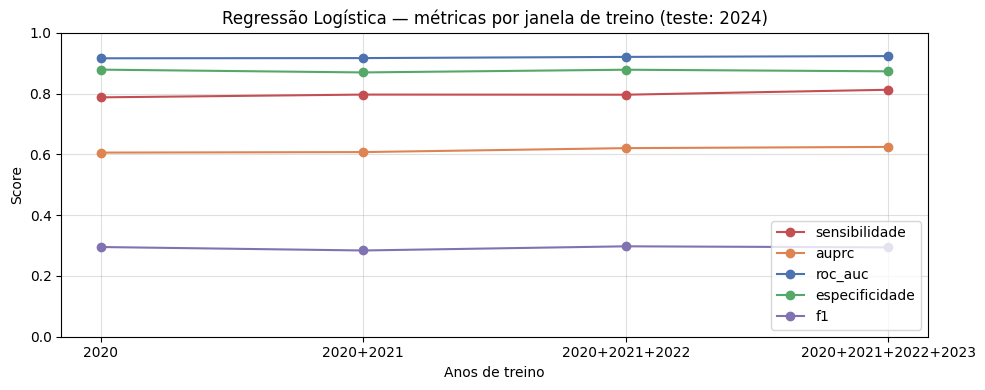

In [22]:
metricas_plot = ['sensibilidade','auprc','roc_auc','especificidade','f1']
cores = ['#C44E52','#DD8452','#4C72B0','#55A868','#8172B2']

fig, ax = plt.subplots(figsize=(10, 4))
for metrica, cor in zip(metricas_plot, cores):
    ax.plot(df_resultados['label'], df_resultados[metrica],
            marker='o', label=metrica, color=cor)

ax.set_title('Regressão Logística — métricas por janela de treino (teste: 2024)')
ax.set_xlabel('Anos de treino')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Modelo final — treino em 2020–2023, avaliação em 2024

In [23]:
X_train_final = prep_X(X_train)
y_train_final = y_train.dropna()
X_train_final = X_train_final.loc[y_train_final.index]

pipeline_final = build_pipeline()
pipeline_final.fit(X_train_final, y_train_final)

proba_final = pipeline_final.predict_proba(X_test_prep)[:, 1]
y_te        = y_test.dropna()
proba_final = proba_final[y_test.notna().values]

metricas_final = calcular_metricas(y_te, proba_final, label='2020-2023')
metricas_final['n_train']       = len(X_train_final)
metricas_final['n_obito_train'] = int(y_train_final.sum())

print('=== Modelo final (2020–2023 → 2024) ===')
for k, v in metricas_final.items():
    print(f'  {k}: {v}')

=== Modelo final (2020–2023 → 2024) ===
  label: 2020-2023
  sensibilidade: 0.8127
  especificidade: 0.8733
  auprc: 0.6246
  roc_auc: 0.9235
  f1: 0.294
  precisao: 0.1795
  threshold: 0.5
  n_train: 149544
  n_obito_train: 2625


              precision    recall  f1-score   support

        Cura       0.99      0.87      0.93    155239
       Óbito       0.18      0.81      0.29      5295

    accuracy                           0.87    160534
   macro avg       0.59      0.84      0.61    160534
weighted avg       0.97      0.87      0.91    160534



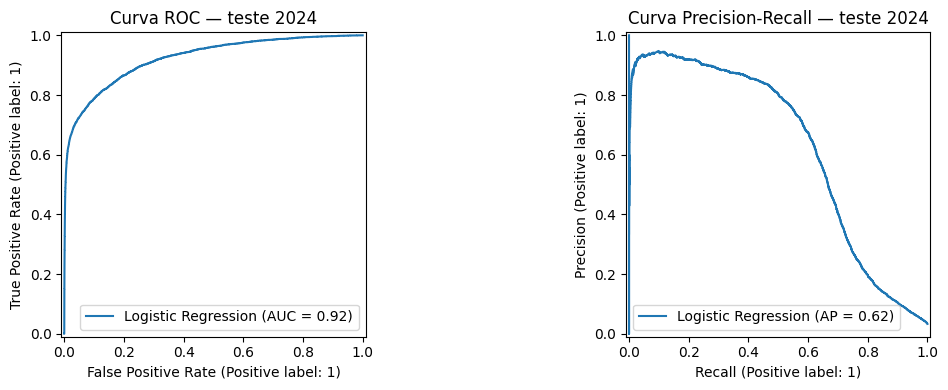

In [24]:
print(classification_report(y_te, (proba_final >= 0.5).astype(int),
                             target_names=['Cura','Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba_final, ax=axes[0],
                                  name='Logistic Regression')
axes[0].set_title('Curva ROC — teste 2024')

PrecisionRecallDisplay.from_predictions(y_te, proba_final, ax=axes[1],
                                         name='Logistic Regression')
axes[1].set_title('Curva Precision-Recall — teste 2024')
plt.tight_layout()
plt.show()

### Matriz de Confusão (threshold = 0.5)

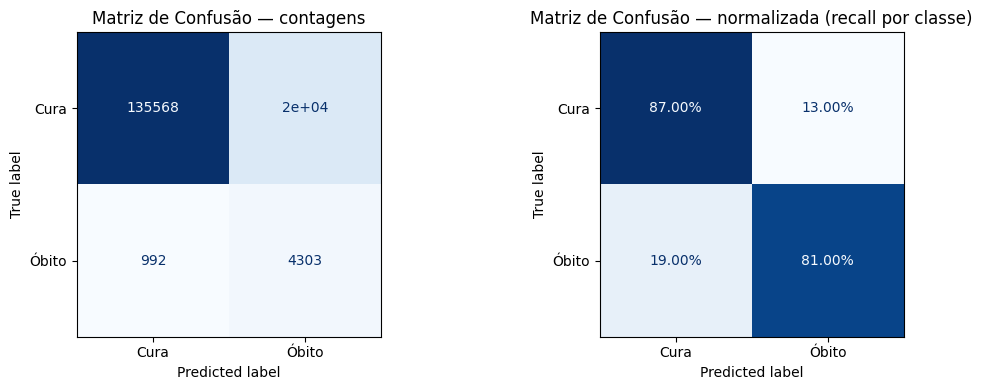

VP (óbitos detectados):   4,303
FN (óbitos perdidos):     992
FP (falsos alarmes):      19,671
VN (curas classificadas): 135,568


In [25]:
y_pred_05 = (proba_final >= 0.5).astype(int)
cm = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada (recall por classe)')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 6.1 Análise de threshold

Threshold padrão  (0.50): sensibilidade=0.8127 | especificidade=0.8733
Threshold Youden  (0.55): sensibilidade=0.7860 | especificidade=0.9015
Threshold sens≥90% (0.30): sensibilidade=0.9131 | especificidade=0.7006


,threshold,sensibilidade,especificidade,precisao,f1,tp,fp,fn,tn
0,0.05,0.9972,0.1140,0.0370,0.0713,5280,137542,15,17697
1,0.10,0.9828,0.3347,0.0480,0.0915,5204,103286,91,51953
2,0.15,0.9666,0.4689,0.0585,0.1102,5118,82442,177,72797
3,0.20,0.9501,0.5646,0.0693,0.1291,5031,67590,264,87649
4,0.25,0.9330,0.6385,0.0809,0.1489,4940,56125,355,99114
5,0.30,0.9131,0.7006,0.0942,0.1708,4835,46484,460,108755
6,0.35,0.8929,0.7527,0.1097,0.1953,4728,38389,567,116850
7,0.40,0.8661,0.7982,0.1277,0.2226,4586,31320,709,123919
8,0.45,0.8376,0.8390,0.1507,0.2554,4435,25000,860,130239
9,0.50,0.8127,0.8733,0.1795,0.2940,4303,19671,992,135568


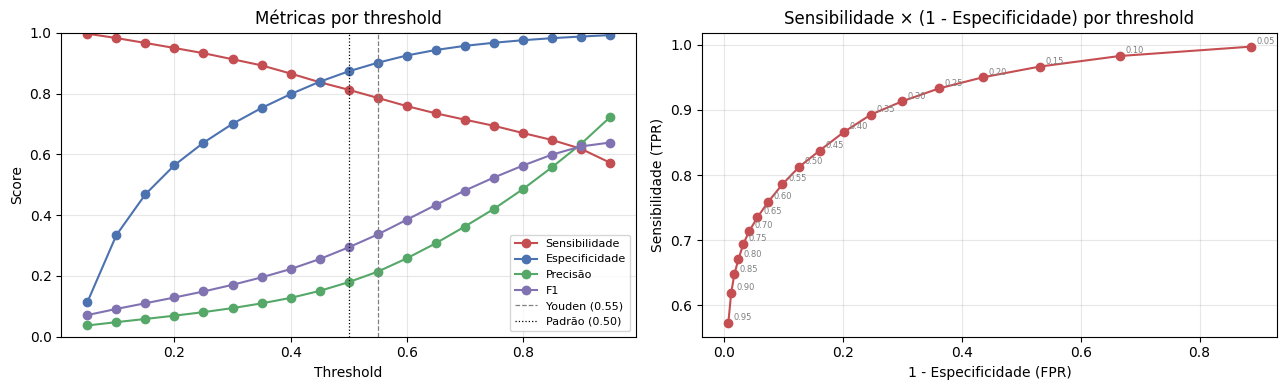

In [26]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    y_pred = (proba_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'threshold':      round(t, 2),
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'precisao':       round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
        'f1':             round(f1_score(y_te, y_pred), 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    })

df_thresh = pd.DataFrame(rows)
df_thresh['youden'] = df_thresh['sensibilidade'] + df_thresh['especificidade'] - 1
idx_youden = df_thresh['youden'].idxmax()

high_sens = df_thresh[df_thresh['sensibilidade'] >= 0.90]
idx_90 = high_sens['especificidade'].idxmax() if not high_sens.empty else None

print(f"Threshold padrão  (0.50): sensibilidade={df_thresh.loc[df_thresh['threshold']==0.50, 'sensibilidade'].values[0]:.4f} | especificidade={df_thresh.loc[df_thresh['threshold']==0.50, 'especificidade'].values[0]:.4f}")
print(f"Threshold Youden  ({df_thresh.loc[idx_youden,'threshold']:.2f}): sensibilidade={df_thresh.loc[idx_youden,'sensibilidade']:.4f} | especificidade={df_thresh.loc[idx_youden,'especificidade']:.4f}")
if idx_90 is not None:
    print(f"Threshold sens≥90% ({df_thresh.loc[idx_90,'threshold']:.2f}): sensibilidade={df_thresh.loc[idx_90,'sensibilidade']:.4f} | especificidade={df_thresh.loc[idx_90,'especificidade']:.4f}")

display(df_thresh.drop(columns='youden'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_thresh['threshold'], df_thresh['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
axes[0].plot(df_thresh['threshold'], df_thresh['especificidade'], 'o-', color='#4C72B0', label='Especificidade')
axes[0].plot(df_thresh['threshold'], df_thresh['precisao'],       'o-', color='#55A868', label='Precisão')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],             'o-', color='#8172B2', label='F1')
axes[0].axvline(df_thresh.loc[idx_youden, 'threshold'], color='gray', linestyle='--', linewidth=0.9, label=f'Youden ({df_thresh.loc[idx_youden,"threshold"]:.2f})')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=0.9, label='Padrão (0.50)')
axes[0].set_title('Métricas por threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(1 - df_thresh['especificidade'], df_thresh['sensibilidade'], 'o-', color='#C44E52')
for _, row in df_thresh.iterrows():
    axes[1].annotate(f"{row['threshold']:.2f}",
                     (1 - row['especificidade'], row['sensibilidade']),
                     textcoords='offset points', xytext=(4, 2), fontsize=6, color='gray')
axes[1].set_title('Sensibilidade × (1 - Especificidade) por threshold')
axes[1].set_xlabel('1 - Especificidade (FPR)')
axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6.2 Importância das features — coeficientes

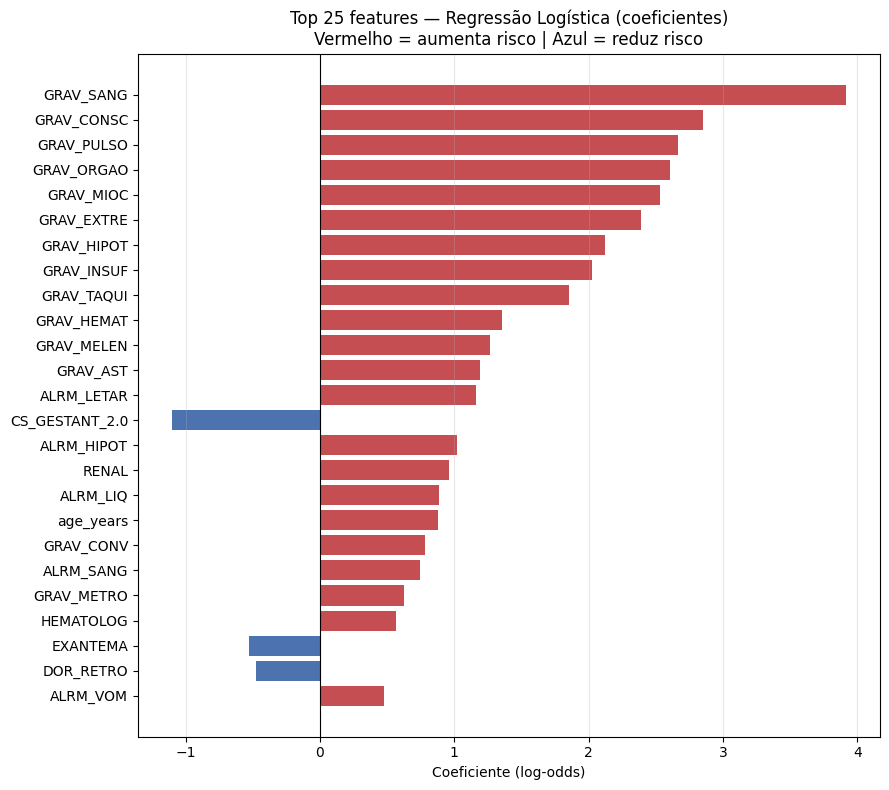

,feature,coeficiente,abs
19,GRAV_SANG,3.917834,3.917834
22,GRAV_CONSC,2.849580,2.849580
9,GRAV_PULSO,2.664527,2.664527
23,GRAV_ORGAO,2.606841,2.606841
21,GRAV_MIOC,2.531880,2.531880
14,GRAV_EXTRE,2.393358,2.393358
15,GRAV_HIPOT,2.121714,2.121714
12,GRAV_INSUF,2.026979,2.026979
13,GRAV_TAQUI,1.857498,1.857498
16,GRAV_HEMAT,1.358996,1.358996


In [27]:
feature_names = pipeline_final['pre'].get_feature_names_out()
coefs         = pipeline_final['clf'].coef_[0]

df_coef = pd.DataFrame({'feature': feature_names, 'coeficiente': coefs})
df_coef['abs'] = df_coef['coeficiente'].abs()
df_coef = df_coef.sort_values('abs', ascending=False)

top_n  = 25
df_top = df_coef.head(top_n)

fig, ax = plt.subplots(figsize=(9, 8))
cores_bar = ['#C44E52' if c > 0 else '#4C72B0' for c in df_top['coeficiente'][::-1]]
ax.barh(df_top['feature'][::-1], df_top['coeficiente'][::-1], color=cores_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} features — Regressão Logística (coeficientes)\nVermelho = aumenta risco | Azul = reduz risco')
ax.set_xlabel('Coeficiente (log-odds)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(df_coef.head(15)[['feature', 'coeficiente', 'abs']])

## 7. Salvamento

In [28]:
os.makedirs(OUTPUT_MOD, exist_ok=True)
os.makedirs(OUTPUT_MET, exist_ok=True)

model_path = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET}.joblib')
joblib.dump(pipeline_final, model_path)
print(f'Modelo salvo: {model_path}')

met_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}.parquet')
df_resultados.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_final})
pred_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Modelo salvo: ../../output/modelos/logistic_regression_baseline.joblib
Métricas salvas: ../../output/metricas/logistic_regression_baseline.parquet
Predições salvas: ../../output/metricas/logistic_regression_baseline_predicoes.parquet


## 8. Otimização de Hiperparâmetros (GridSearchCV)
Busca exaustiva sobre `C` e `penalty`. Avaliação por `StratifiedKFold(5)` dentro do train set (2020–2023).
Scoring: `average_precision` (AUPRC) — threshold-independente e métrica prioritária #2.

Grid testado:
- `penalty=l2` + `solver=lbfgs` (mesmo do baseline) com C em [0.01, 0.1, 1, 10]
- `penalty=l1` + `solver=liblinear` com C em [0.01, 0.1, 1, 10]

Total: 8 combinações × 5 folds = 40 fits.

In [29]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = [
    {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs']},
    {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1'], 'clf__solver': ['liblinear']},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=build_pipeline(),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train_final, y_train_final)

print(f'\nMelhores parâmetros: {grid_search.best_params_}')
print(f'Melhor AUPRC (CV):   {grid_search.best_score_:.4f}')

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv = df_cv[['param_clf__C', 'param_clf__penalty', 'param_clf__solver',
               'mean_test_score', 'std_test_score', 'rank_test_score']]
df_cv = df_cv.sort_values('rank_test_score')
display(df_cv)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Melhores parâmetros: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Melhor AUPRC (CV):   0.6167


,param_clf__C,param_clf__penalty,param_clf__solver,mean_test_score,std_test_score,rank_test_score
3,10.00,l2,lbfgs,0.616702,0.018916,1
6,1.00,l1,liblinear,0.616649,0.018755,2
7,10.00,l1,liblinear,0.616576,0.018642,3
2,1.00,l2,lbfgs,0.616339,0.018871,4
5,0.10,l1,liblinear,0.615925,0.018604,5
1,0.10,l2,lbfgs,0.615017,0.019221,6
4,0.01,l1,liblinear,0.610455,0.018154,7
0,0.01,l2,lbfgs,0.606695,0.020416,8


## 9. Avaliação — Modelo Tunado

=== Comparação: Baseline vs Tunado ===
Métrica              Baseline     Tunado
----------------------------------------
sensibilidade          0.8127     0.8130  (+0.0003)
especificidade         0.8733     0.8730  (-0.0003)
auprc                  0.6246     0.6248  (+0.0002)
roc_auc                0.9235     0.9236  (+0.0001)
f1                     0.2940     0.2937  (-0.0003)


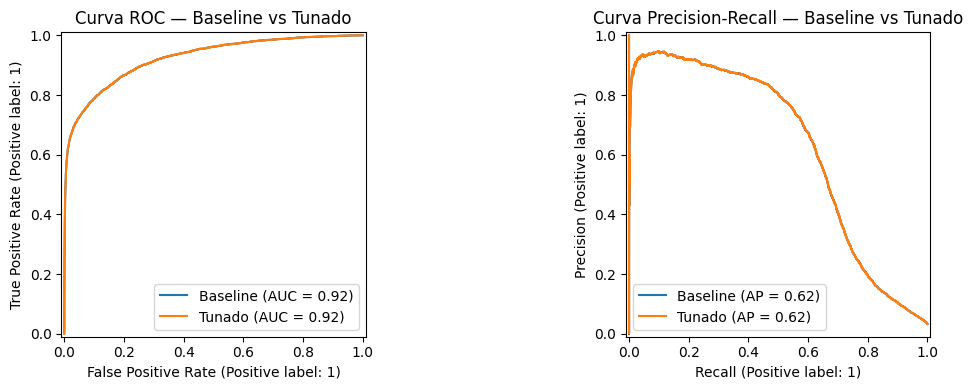

In [30]:
pipeline_tuned = grid_search.best_estimator_

proba_tuned    = pipeline_tuned.predict_proba(X_test_prep)[:, 1]
proba_tuned    = proba_tuned[y_test.notna().values]

metricas_tuned = calcular_metricas(y_te, proba_tuned, label='2020-2023 (tuned)')
metricas_tuned['n_train']       = len(X_train_final)
metricas_tuned['n_obito_train'] = int(y_train_final.sum())

print('=== Comparação: Baseline vs Tunado ===')
print(f"{'Métrica':<18} {'Baseline':>10} {'Tunado':>10}")
print('-' * 40)
for k in ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']:
    v_base  = metricas_final[k]
    v_tuned = metricas_tuned[k]
    diff    = v_tuned - v_base
    sinal   = '+' if diff >= 0 else ''
    print(f'{k:<18} {v_base:>10.4f} {v_tuned:>10.4f}  ({sinal}{diff:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba_final, ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_te, proba_tuned, ax=axes[0], name='Tunado')
axes[0].set_title('Curva ROC — Baseline vs Tunado')

PrecisionRecallDisplay.from_predictions(y_te, proba_final, ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_te, proba_tuned, ax=axes[1], name='Tunado')
axes[1].set_title('Curva Precision-Recall — Baseline vs Tunado')
plt.tight_layout()
plt.show()

## 10. Salvamento — Modelo Tunado

In [31]:
DATASET_TUNED = f'{DATASET}_tuned'

model_path_tuned = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET_TUNED}.joblib')
joblib.dump(pipeline_tuned, model_path_tuned)
print(f'Modelo salvo: {model_path_tuned}')

df_met_tuned = pd.DataFrame([metricas_tuned])
df_met_tuned['label']       = f'{ALGO}_{DATASET_TUNED}'
df_met_tuned['dataset']     = DATASET_TUNED
df_met_tuned['best_params'] = str(grid_search.best_params_)
met_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}.parquet')
df_met_tuned.to_parquet(met_path_tuned, index=False)
print(f'Métricas salvas: {met_path_tuned}')

df_pred_tuned = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_tuned})
pred_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}_predicoes.parquet')
df_pred_tuned.to_parquet(pred_path_tuned, index=False)
print(f'Predições salvas: {pred_path_tuned}')

Modelo salvo: ../../output/modelos/logistic_regression_baseline_tuned.joblib
Métricas salvas: ../../output/metricas/logistic_regression_baseline_tuned.parquet
Predições salvas: ../../output/metricas/logistic_regression_baseline_tuned_predicoes.parquet


## 11. Experimento — sem class_weight='balanced'
Avalia o impacto da ponderação de classes removendo `class_weight='balanced'`.
Expectativa: queda expressiva de sensibilidade, ganho de especificidade.

=== Comparação: com vs sem class_weight="balanced" ===
Métrica              Com peso   Sem peso        Δ
--------------------------------------------------
sensibilidade          0.8127     0.4261  (-0.3866)
especificidade         0.8733     0.9975  (+0.1242)
auprc                  0.6246     0.6233  (-0.0013)
roc_auc                0.9235     0.9212  (-0.0023)
f1                     0.2940     0.5688  (+0.2748)


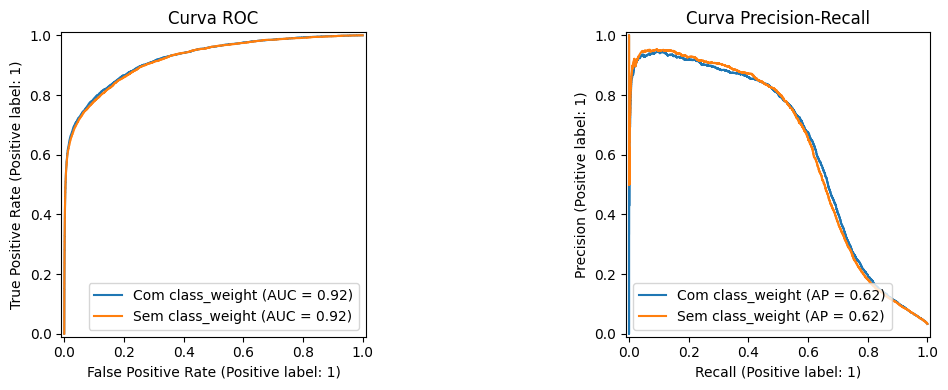

In [32]:
pipeline_no_weight = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        class_weight=None,
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
    )),
])

pipeline_no_weight.fit(X_train_final, y_train_final)
proba_no_weight = pipeline_no_weight.predict_proba(X_test_prep)[:, 1][y_test.notna().values]
metricas_no_weight = calcular_metricas(y_te, proba_no_weight, label='sem class_weight')

print('=== Comparação: com vs sem class_weight="balanced" ===')
print(f"{'Métrica':<18} {'Com peso':>10} {'Sem peso':>10} {'Δ':>8}")
print('-' * 50)
for k in ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']:
    v_com  = metricas_final[k]
    v_sem  = metricas_no_weight[k]
    diff   = v_sem - v_com
    sinal  = '+' if diff >= 0 else ''
    print(f'{k:<18} {v_com:>10.4f} {v_sem:>10.4f}  ({sinal}{diff:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba_final,     ax=axes[0], name='Com class_weight')
RocCurveDisplay.from_predictions(y_te, proba_no_weight, ax=axes[0], name='Sem class_weight')
axes[0].set_title('Curva ROC')

PrecisionRecallDisplay.from_predictions(y_te, proba_final,     ax=axes[1], name='Com class_weight')
PrecisionRecallDisplay.from_predictions(y_te, proba_no_weight, ax=axes[1], name='Sem class_weight')
axes[1].set_title('Curva Precision-Recall')
plt.tight_layout()
plt.show()